##**FUNDAMENTOS DE PROCESAMIENTO DE LENGUAJE NATURAL**
##*COMPETENCIA FINAL*

Presentado por:

*   Diego Andres Burbano Arturo
*   Juan Manuel Arenas Pardo
*   Ormar Dario Díaz Hernandez
*   Ana Milena Sánchez Villamil
*   Miguel Uruena Riobo

**1.  Carga de librerias**

In [1]:
import re
import gc
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from google.colab import drive

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

**2. Montaje de rutas**

In [2]:
drive.mount("/content/drive", force_remount=True)

PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/MaestriaUniandesColabs/NLP")
DATA_DIR = PROJECT_DIR / "data"
MODELS_DIR = PROJECT_DIR / "models"
SUB_DIR = PROJECT_DIR / "submissions"

for p in [DATA_DIR, MODELS_DIR, SUB_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
EVAL_PATH = DATA_DIR / "eval.csv"


Mounted at /content/drive


**3. Carga y preparación de datos**

3.1 Carga y verificación del dataset

In [3]:
df_train = pd.read_csv(TRAIN_PATH)
df_eval = pd.read_csv(EVAL_PATH)

print("Train shape:", df_train.shape)
print("Eval shape :", df_eval.shape)
df_train.head()

Train shape: (46674, 4)
Eval shape : (5186, 3)


,id,sequence,original_label,is_mutated
0,4199,GTCTGTTATTGTTTATTGATGGCAGACACTCGCGTCTTACGACGAA...,Leviviricetes,1
1,42083,GATTAAGACCAACTTTAGATAGAATTTCAGAGAATTCATAACGTTG...,Malgrandaviricetes,1
2,15249,AGCCCACTTATCAATCGTGAGCGTGACCTTGTATGTCTGCGCGAGA...,Faserviricetes,1
3,44043,TCATGGAGGACGACGGGATTTTGACGGCTGTGAGGACCGCCGACTG...,Caudoviricetes,1
4,36019,GCGCTTTAATCGATTAAAATCAACAAAGAGCTCACTAACATTAGTA...,Leviviricetes,0


3.2  Revisión de duplicados

In [4]:
duplicados = df_train['sequence'].duplicated().sum()
print(f"Número de secuencias duplicadas: {duplicados}")

Número de secuencias duplicadas: 3


3.3 Revisión de datos nulos

In [5]:
nulos_secuencia = df_train['sequence'].isnull().sum()
print(f"Valores nulos en 'sequence': {nulos_secuencia}")

Valores nulos en 'sequence': 0


3.4  Exploración de balanceo de clases

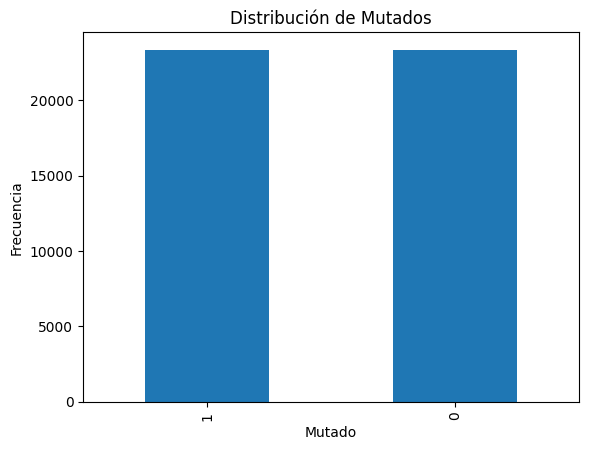

In [6]:
df_train['is_mutated'].value_counts().plot(kind='bar')
plt.title('Distribución de Mutados')
plt.xlabel('Mutado')
plt.ylabel('Frecuencia')
plt.show()

3.5 El set de entrenamiento se divide 80% para entrenar y 20% para evaluar



**4. Transformador de K-Mers**

Se ejecuta limpieza de datos
* Se convierte a mayúsculas
* Se eliminan espacios
* Se eliminan carácteres no validos al patron ADN


In [7]:


# =========================
# 1. LIMPIEZA
# =========================
def limpiar_secuencia(seq):
    seq = str(seq).upper().strip()
    seq = re.sub(r"[^ACGT]", "", seq)
    return seq

df_train["sequence_clean"] = df_train["sequence"].apply(limpiar_secuencia)
df_eval["sequence_clean"] = df_eval["sequence"].apply(limpiar_secuencia)

# =========================
# 2. FEATURES NUMÉRICAS
# =========================
class DNAStatsTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        feats = []
        for seq in X:
            seq = str(seq)
            n = len(seq) if len(seq) > 0 else 1

            a = seq.count("A") / n
            c = seq.count("C") / n
            g = seq.count("G") / n
            t = seq.count("T") / n
            gc = (seq.count("G") + seq.count("C")) / n

            # cambios entre bases consecutivas
            cambios = sum(seq[i] != seq[i+1] for i in range(len(seq)-1))
            cambios = cambios / n

            # máxima repetición consecutiva
            max_run = 1
            run = 1
            for i in range(1, len(seq)):
                if seq[i] == seq[i-1]:
                    run += 1
                    max_run = max(max_run, run)
                else:
                    run = 1

            feats.append([n, a, c, g, t, gc, cambios, max_run])

        return np.array(feats, dtype=np.float32)

# =========================
# 3. FEATURE UNION
# =========================
text_features = FeatureUnion([
    ("tfidf_36", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 6),
        lowercase=False,
        min_df=2,
        max_features=250000,
        binary=True
    )),
    ("tfidf_47", TfidfVectorizer(
        analyzer="char",
        ngram_range=(4, 7),
        lowercase=False,
        min_df=4,
        max_features=300000,
        binary=True
    ))
])

preprocessor = ColumnTransformer([
    ("text", text_features, "sequence_clean"),
    ("stats", Pipeline([
        ("dna_stats", DNAStatsTransformer()),
        ("scaler", StandardScaler())
    ]), "sequence_clean")
])

pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        C=0.5,
        solver="liblinear",
        max_iter=3000,
        random_state=42
    ))
])

# =========================
# 4. SPLIT
# =========================
X = df_train[["sequence_clean"]]
y = df_train["is_mutated"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)





**5. Construcción del pipeline**

Se define k

**6. Entrenamiento**

In [8]:
# ENTRENAR
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('text',
                                                  FeatureUnion(transformer_list=[('tfidf_36',
                                                                                  TfidfVectorizer(analyzer='char',
                                                                                                  binary=True,
                                                                                                  lowercase=False,
                                                                                                  max_features=250000,
                                                                                                  min_df=2,
                                                                                                  ngram_range=(3,
                                                                                                               6))),
                                                                                 ('tfidf_47',
                                                                                  TfidfVectorizer(analyzer='char',
                                                                                                  binary=True,
                                                                                                  lowercase=False,
                                                                                                  max_features=300000,
                                                                                                  min_df=4,
                                                                                                  ngram_range=(4,
                                                                                                               7)))]),
                                                  'sequence_clean'),
                                                 ('stats',
                                                  Pipeline(steps=[('dna_stats',
                                                                   DNAStatsTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  'sequence_clean')])),
                ('clf',
                 LogisticRegression(C=0.5, max_iter=3000, random_state=42,
                                    solver='liblinear'))])

In [9]:
# BUSCAR MEJOR UMBRAL PARA F1
val_probs = pipeline.predict_proba(X_val)[:, 1]

best_thr = 0.5
best_f1 = 0.0

for thr in np.arange(0.20, 0.81, 0.01):
    preds = (val_probs >= thr).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print(f"Mejor threshold: {best_thr:.2f}")
print(f"Mejor F1       : {best_f1:.4f}")



Mejor threshold: 0.42
Mejor F1       : 0.7436


**7.  Evaluación**

In [10]:
# evaluación final en validación
y_pred = (val_probs >= best_thr).astype(int)

acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f"Accuracy de validación: {acc:.4f}")
print(f"F1 de validación      : {f1:.4f}")
print(classification_report(y_val, y_pred, digits=4))


Accuracy de validación: 0.6999
F1 de validación      : 0.7436
              precision    recall  f1-score   support

           0     0.8024    0.5301    0.6384      4665
           1     0.6494    0.8696    0.7436      4670

    accuracy                         0.6999      9335
   macro avg     0.7259    0.6999    0.6910      9335
weighted avg     0.7259    0.6999    0.6910      9335



**8.  Entrenamiento con todo el set de entrenamiento**

In [11]:
# REENTRENAR CON TODO TRAIN
X_full = df_train[["sequence_clean"]]
y_full = df_train["is_mutated"]

pipeline.fit(X_full, y_full)

print("Modelo reentrenado con todo el conjunto de entrenamiento.")

Modelo reentrenado con todo el conjunto de entrenamiento.


**9.  Guardar el modelo**

In [12]:
# GUARDAR MODELO
MODEL_PATH = MODELS_DIR / "modelo_final_f1_optimizado.joblib"
joblib.dump(pipeline, MODEL_PATH)

print(f"Modelo guardado en: {MODEL_PATH}")


Modelo guardado en: /content/drive/MyDrive/Colab Notebooks/MaestriaUniandesColabs/NLP/models/modelo_final_f1_optimizado.joblib


**10. Predicción en el set de evaluación para la competencia**

In [ ]:
# GENERAR PREDICCIONES EN EVAL
X_eval = df_eval[["sequence_clean"]]

eval_probs = pipeline.predict_proba(X_eval)[:, 1]
eval_preds = (eval_probs >= best_thr).astype(int)


# CREAR SUBMISSION
if "id" in df_eval.columns:
    submission = pd.DataFrame({
        "id": df_eval["id"],
        "answer": eval_preds
    })
else:
    submission = pd.DataFrame({
        "id": df_eval.index,
        "answer": eval_preds
    })

SUB_PATH = SUB_DIR / "submission_modelo_final_thr_042.csv"
submission.to_csv(SUB_PATH, index=False)

print(f"Submission guardada en: {SUB_PATH}")
print(submission.head())